# 第26章: その他の多変量解析手法

## 学習目標
- 正準相関分析を理解し適用できる
- 多次元尺度構成法を実行できる
- 対応分析を理解し解釈できる

## 📋 学習メタ情報

### 推定学習時間
**110〜140分**

### 難易度
**★★★★☆** (5段階中4)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.linalg import svd, eigh
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
from sklearn.cross_decomposition import CCA
from sklearn.manifold import MDS

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 26.1 正準相関分析

### 目的
2つの変数群 $\mathbf{X}$ と $\mathbf{Y}$ の間の関係を分析

### 正準変数
$$U = \mathbf{a}^T \mathbf{X}, \quad V = \mathbf{b}^T \mathbf{Y}$$

### 最適化問題
$$\rho = \max_{\mathbf{a}, \mathbf{b}} \text{Corr}(U, V)$$

制約: $\text{Var}(U) = \text{Var}(V) = 1$

### 解法
$$\mathbf{\Sigma}_{XX}^{-1/2} \mathbf{\Sigma}_{XY} \mathbf{\Sigma}_{YY}^{-1} \mathbf{\Sigma}_{YX} \mathbf{\Sigma}_{XX}^{-1/2} \mathbf{a}^* = \rho^2 \mathbf{a}^*$$

In [2]:
# 正準相関分析
np.random.seed(123)

n = 200

# Generate correlated data
# X variables (3 variables)
# Y variables (2 variables)

# Latent variables
z1 = np.random.randn(n)
z2 = np.random.randn(n)

# X variables depend on z1 and z2
X1 = 0.8*z1 + 0.3*z2 + 0.3*np.random.randn(n)
X2 = 0.7*z1 + 0.4*z2 + 0.3*np.random.randn(n)
X3 = 0.6*z1 + 0.5*z2 + 0.3*np.random.randn(n)

# Y variables also depend on z1 and z2
Y1 = 0.9*z1 + 0.2*z2 + 0.3*np.random.randn(n)
Y2 = 0.3*z1 + 0.8*z2 + 0.3*np.random.randn(n)

X = np.column_stack([X1, X2, X3])
Y = np.column_stack([Y1, Y2])

print("正準相関分析")
print("="*60)
print(f"\nサンプルサイズ: n = {n}")
print(f"X変数の数: p = {X.shape[1]}")
print(f"Y変数の数: q = {Y.shape[1]}")

正準相関分析

サンプルサイズ: n = 200
X変数の数: p = 3
Y変数の数: q = 2


In [3]:
# Implement CCA
def canonical_correlation_analysis(X, Y):
    """Perform canonical correlation analysis."""
    n = X.shape[0]
    p = X.shape[1]
    q = Y.shape[1]
    
    # Center data
    X_c = X - np.mean(X, axis=0)
    Y_c = Y - np.mean(Y, axis=0)
    
    # Covariance matrices
    Sxx = (X_c.T @ X_c) / (n - 1)
    Syy = (Y_c.T @ Y_c) / (n - 1)
    Sxy = (X_c.T @ Y_c) / (n - 1)
    
    # Solve eigenvalue problem
    Sxx_inv_sqrt = np.linalg.inv(np.linalg.cholesky(Sxx)).T
    Syy_inv = np.linalg.inv(Syy)
    
    M = Sxx_inv_sqrt @ Sxy @ Syy_inv @ Sxy.T @ Sxx_inv_sqrt.T
    
    eigenvalues, eigenvectors = np.linalg.eigh(M)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Canonical correlations
    canon_corr = np.sqrt(np.maximum(eigenvalues, 0))
    
    # Canonical coefficients
    A = Sxx_inv_sqrt.T @ eigenvectors
    B = Syy_inv @ Sxy.T @ A / canon_corr
    
    return canon_corr, A, B

# Apply CCA
canon_corr, A, B = canonical_correlation_analysis(X, Y)

print("\n正準相関係数:")
for i, r in enumerate(canon_corr):
    print(f"  ρ_{i+1} = {r:.4f}")

print("\nX側の正準係数:")
print(A.round(3))

print("\nY側の正準係数:")
print(B.round(3))


正準相関係数:
  ρ_1 = 2.4417
  ρ_2 = 0.2692
  ρ_3 = 0.0000

X側の正準係数:
[[-0.5   -0.298  0.886]
 [ 1.481 -1.65  -1.981]
 [ 2.236  2.119  1.164]]

Y側の正準係数:
[[ 0.62  -1.034 -0.   ]
 [ 0.647  1.204  0.   ]]


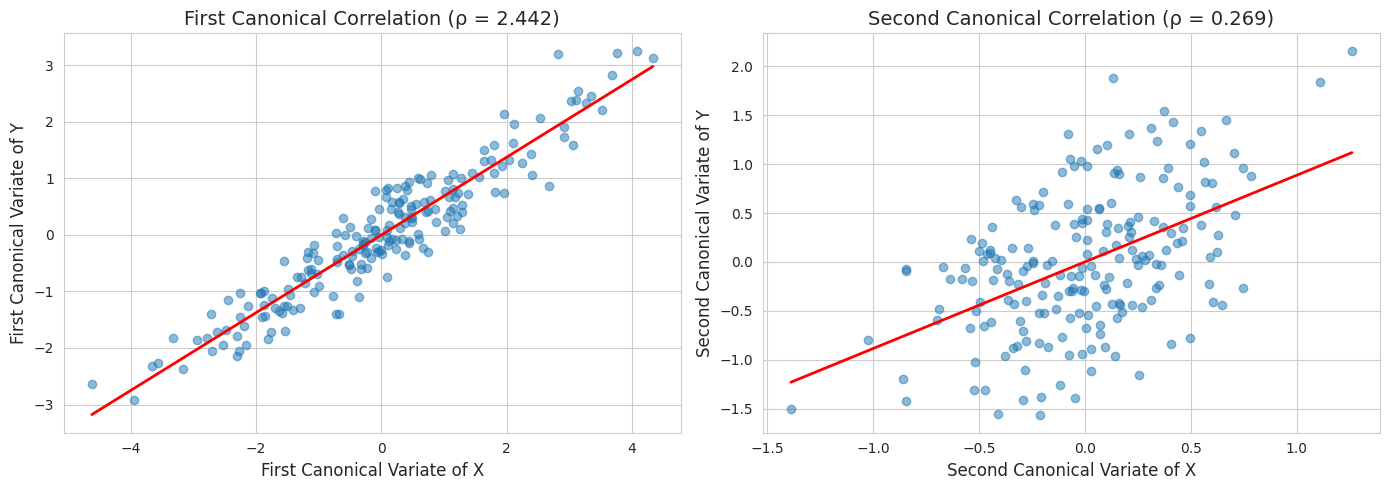

In [4]:
# Using sklearn
cca = CCA(n_components=2)
X_c, Y_c = cca.fit_transform(X, Y)

# Visualize canonical variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# First canonical variates
axes[0].scatter(X_c[:, 0], Y_c[:, 0], alpha=0.5)
axes[0].set_xlabel('First Canonical Variate of X', fontsize=12)
axes[0].set_ylabel('First Canonical Variate of Y', fontsize=12)
axes[0].set_title(f'First Canonical Correlation (ρ = {canon_corr[0]:.3f})', fontsize=14)

# Add regression line
z = np.polyfit(X_c[:, 0], Y_c[:, 0], 1)
p_line = np.poly1d(z)
x_line = np.linspace(X_c[:, 0].min(), X_c[:, 0].max(), 100)
axes[0].plot(x_line, p_line(x_line), 'r-', linewidth=2)

# Second canonical variates
axes[1].scatter(X_c[:, 1], Y_c[:, 1], alpha=0.5)
axes[1].set_xlabel('Second Canonical Variate of X', fontsize=12)
axes[1].set_ylabel('Second Canonical Variate of Y', fontsize=12)
axes[1].set_title(f'Second Canonical Correlation (ρ = {canon_corr[1]:.3f})', fontsize=14)

# Add regression line
z = np.polyfit(X_c[:, 1], Y_c[:, 1], 1)
p_line = np.poly1d(z)
x_line = np.linspace(X_c[:, 1].min(), X_c[:, 1].max(), 100)
axes[1].plot(x_line, p_line(x_line), 'r-', linewidth=2)

plt.tight_layout()
plt.show()

## 26.2 多次元尺度構成法 (MDS)

### 目的
距離行列から低次元空間での配置を求める

### 古典的MDS
Strain を最小化:
$$\text{Strain} = \sum_{i<j} (d_{ij} - ||\mathbf{x}_i - \mathbf{x}_j||)^2$$

### アルゴリズム
1. 距離行列 $\mathbf{D}$ から内積行列 $\mathbf{B}$ を計算
2. $\mathbf{B}$ を固有値分解
3. 上位 $k$ 個の固有値・固有ベクトルから座標を算出

In [5]:
# 多次元尺度構成法
np.random.seed(456)

# Create sample data with cluster structure
n = 50
X_mds = np.vstack([
    np.random.randn(n//2, 5) + [0, 0, 0, 0, 0],
    np.random.randn(n//2, 5) + [3, 3, 0, 0, 0]
])
labels = np.array([0]*(n//2) + [1]*(n//2))

# Calculate distance matrix
D = squareform(pdist(X_mds, 'euclidean'))

print("多次元尺度構成法 (MDS)")
print("="*60)
print(f"\n元データ: {X_mds.shape[0]} サンプル × {X_mds.shape[1]} 変数")

# Classical MDS
def classical_mds(D, n_components=2):
    """Classical (metric) MDS."""
    n = D.shape[0]
    
    # Centering matrix
    H = np.eye(n) - np.ones((n, n)) / n
    
    # Double centering
    B = -0.5 * H @ (D**2) @ H
    
    # Eigenvalue decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(B)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Select top components
    eigenvalues = eigenvalues[:n_components]
    eigenvectors = eigenvectors[:, :n_components]
    
    # Compute coordinates
    X_mds = eigenvectors * np.sqrt(np.maximum(eigenvalues, 0))
    
    return X_mds, eigenvalues

# Apply MDS
X_mds_result, eigenvalues_mds = classical_mds(D, 2)

# Stress calculation
D_mds = squareform(pdist(X_mds_result, 'euclidean'))
stress = np.sqrt(np.sum((D - D_mds)**2) / np.sum(D**2))

print(f"\n固有値: {eigenvalues_mds}")
print(f"Stress: {stress:.4f}")

多次元尺度構成法 (MDS)

元データ: 50 サンプル × 5 変数

固有値: [280.16554973  68.79578073]
Stress: 0.2298


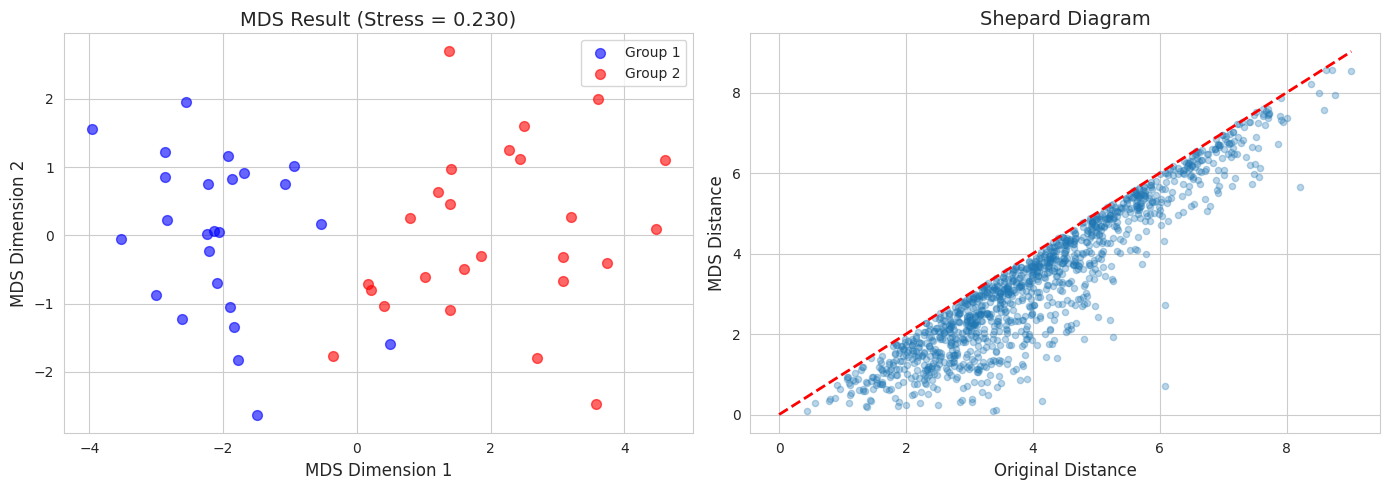

In [6]:
# Visualize MDS result
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MDS result
colors = ['blue', 'red']
for label in [0, 1]:
    mask = labels == label
    axes[0].scatter(X_mds_result[mask, 0], X_mds_result[mask, 1], 
                    c=colors[label], alpha=0.6, s=50, label=f'Group {label+1}')
axes[0].set_xlabel('MDS Dimension 1', fontsize=12)
axes[0].set_ylabel('MDS Dimension 2', fontsize=12)
axes[0].set_title(f'MDS Result (Stress = {stress:.3f})', fontsize=14)
axes[0].legend()

# Shepard diagram
D_flat = D[np.triu_indices(n, k=1)]
D_mds_flat = D_mds[np.triu_indices(n, k=1)]

axes[1].scatter(D_flat, D_mds_flat, alpha=0.3, s=20)
max_d = max(D_flat.max(), D_mds_flat.max())
axes[1].plot([0, max_d], [0, max_d], 'r--', linewidth=2)
axes[1].set_xlabel('Original Distance', fontsize=12)
axes[1].set_ylabel('MDS Distance', fontsize=12)
axes[1].set_title('Shepard Diagram', fontsize=14)

plt.tight_layout()
plt.show()

## 26.3 対応分析

### 目的
分割表の行と列の関係を低次元空間で可視化

### 方法
1. 分割表を相対度数に変換
2. 独立を仮定した期待度数からの偏差を計算
3. SVDを適用

### 解釈
- 行と列を同一空間にプロット
- 近い点は関連が強い

In [7]:
# 対応分析
np.random.seed(789)

# Create contingency table
# Rows: Age groups, Columns: Preferences
contingency = np.array([
    [30, 50, 20, 10],   # 20s
    [25, 45, 35, 15],   # 30s
    [15, 30, 40, 25],   # 40s
    [10, 20, 35, 45],   # 50s+
])

row_labels = ['20代', '30代', '40代', '50代+']
col_labels = ['A', 'B', 'C', 'D']

print("対応分析")
print("="*60)
print("\n分割表:")
print(f"{'':>8}", end="")
for col in col_labels:
    print(f"{col:>8}", end="")
print()
for i, row in enumerate(row_labels):
    print(f"{row:>8}", end="")
    for j in range(len(col_labels)):
        print(f"{contingency[i, j]:>8}", end="")
    print()

対応分析

分割表:
               A       B       C       D
     20代      30      50      20      10
     30代      25      45      35      15
     40代      15      30      40      25
    50代+      10      20      35      45


In [8]:
def correspondence_analysis(P):
    """Perform correspondence analysis."""
    # Total
    n = P.sum()
    
    # Correspondence matrix
    F = P / n
    
    # Marginals
    r = F.sum(axis=1)  # Row masses
    c = F.sum(axis=0)  # Column masses
    
    # Expected frequencies under independence
    E = np.outer(r, c)
    
    # Standardized residuals
    Dr_inv_sqrt = np.diag(1 / np.sqrt(r))
    Dc_inv_sqrt = np.diag(1 / np.sqrt(c))
    
    S = Dr_inv_sqrt @ (F - E) @ Dc_inv_sqrt
    
    # SVD
    U, sigma, Vt = svd(S, full_matrices=False)
    
    # Row and column coordinates (principal)
    row_coords = Dr_inv_sqrt @ U * sigma
    col_coords = Dc_inv_sqrt @ Vt.T * sigma
    
    # Inertia
    inertia = sigma**2
    
    return row_coords, col_coords, inertia

# Apply correspondence analysis
row_coords, col_coords, inertia = correspondence_analysis(contingency)

total_inertia = np.sum(inertia)
print(f"\n総慣性 (total inertia): {total_inertia:.4f}")
print(f"\n各次元の寄与率:")
for i in range(len(inertia)):
    print(f"  次元{i+1}: {inertia[i]/total_inertia:.1%}")


総慣性 (total inertia): 0.1459

各次元の寄与率:
  次元1: 92.6%
  次元2: 7.4%
  次元3: 0.0%
  次元4: 0.0%


/tmp/ipykernel_31743/4150443228.py:23: UserWarning: Glyph 20195 (\N{CJK UNIFIED IDEOGRAPH-4EE3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/root/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20195 (\N{CJK UNIFIED IDEOGRAPH-4EE3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


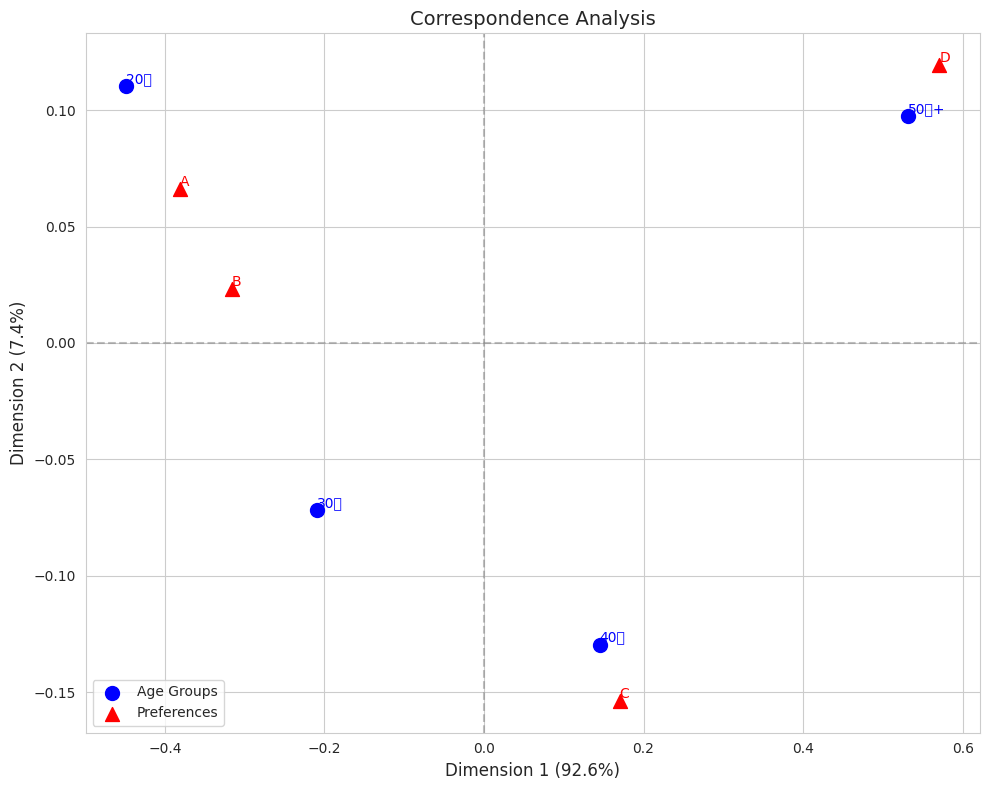


解釈:
・20代とAが近い → 若い層はAを好む
・50代+とDが近い → 高齢層はDを好む


In [9]:
# Visualize correspondence analysis
fig, ax = plt.subplots(figsize=(10, 8))

# Plot row points
ax.scatter(row_coords[:, 0], row_coords[:, 1], c='blue', s=100, marker='o', label='Age Groups')
for i, label in enumerate(row_labels):
    ax.annotate(label, (row_coords[i, 0], row_coords[i, 1]), 
                fontsize=10, ha='left', va='bottom', color='blue')

# Plot column points
ax.scatter(col_coords[:, 0], col_coords[:, 1], c='red', s=100, marker='^', label='Preferences')
for i, label in enumerate(col_labels):
    ax.annotate(label, (col_coords[i, 0], col_coords[i, 1]), 
                fontsize=10, ha='left', va='bottom', color='red')

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel(f'Dimension 1 ({inertia[0]/total_inertia:.1%})', fontsize=12)
ax.set_ylabel(f'Dimension 2 ({inertia[1]/total_inertia:.1%})', fontsize=12)
ax.set_title('Correspondence Analysis', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

print("\n解釈:")
print("・20代とAが近い → 若い層はAを好む")
print("・50代+とDが近い → 高齢層はDを好む")

## 26.4 練習問題

### 問題1
正準相関分析と重回帰分析の関係を説明せよ。

### 問題2
MDSのstressが大きい場合、どのような対処が考えられるか。

### 問題3
対応分析において慣性（inertia）は何を表すか。

In [10]:
# 問題1の解答
print("問題1: 正準相関分析と重回帰分析")
print("="*60)

print("""
【関係】
重回帰分析は正準相関分析の特殊ケース

【重回帰分析】
- Y変数が1つ (q = 1)
- X変数が複数 (p > 1)
- 1つの正準相関のみ存在

【正準相関分析】
- Y変数も複数 (q > 1)
- min(p, q) 個の正準相関が存在
- XとYの関係をより包括的に分析

【数学的関係】
Y が1変数の場合:
ρ² = R²（重相関係数の二乗 = 決定係数）
""")

問題1: 正準相関分析と重回帰分析

【関係】
重回帰分析は正準相関分析の特殊ケース

【重回帰分析】
- Y変数が1つ (q = 1)
- X変数が複数 (p > 1)
- 1つの正準相関のみ存在

【正準相関分析】
- Y変数も複数 (q > 1)
- min(p, q) 個の正準相関が存在
- XとYの関係をより包括的に分析

【数学的関係】
Y が1変数の場合:
ρ² = R²（重相関係数の二乗 = 決定係数）



In [11]:
# 問題2の解答
print("問題2: MDSのstress対策")
print("="*60)

print("""
【Stressが大きい場合の対処】

1. 次元数を増やす
   - より多くの次元で表現
   - ただし解釈が難しくなる

2. 非計量MDS（順序MDS）を使用
   - 距離の順序関係のみを保持
   - より柔軟な表現

3. 外れ値の検討
   - 特異な観測値がないか確認
   - 必要に応じて除外

4. 距離尺度の変更
   - ユークリッド以外の距離を試す
   - データの性質に合った距離

5. 局所的最適解の回避
   - 異なる初期値で複数回実行
   - 最良の結果を採用

【Stressの目安】
< 0.05: 優
< 0.10: 良
< 0.20: 可
> 0.20: 不十分
""")

問題2: MDSのstress対策

【Stressが大きい場合の対処】

1. 次元数を増やす
   - より多くの次元で表現
   - ただし解釈が難しくなる

2. 非計量MDS（順序MDS）を使用
   - 距離の順序関係のみを保持
   - より柔軟な表現

3. 外れ値の検討
   - 特異な観測値がないか確認
   - 必要に応じて除外

4. 距離尺度の変更
   - ユークリッド以外の距離を試す
   - データの性質に合った距離

5. 局所的最適解の回避
   - 異なる初期値で複数回実行
   - 最良の結果を採用

【Stressの目安】
< 0.05: 優
< 0.10: 良
< 0.20: 可
> 0.20: 不十分



In [12]:
# 問題3の解答
print("問題3: 対応分析の慣性")
print("="*60)

print("""
【慣性 (Inertia) とは】
分割表における独立からの総乖離量

【定義】
総慣性 = Σᵢⱼ (観測度数 - 期待度数)² / 期待度数
       = χ² / n

【意味】
1. 行と列の関連の強さ
   - 大きい → 強い関連
   - 小さい → 独立に近い

2. 各次元が説明する関連性の割合
   - 第1次元: 最も重要な関連パターン
   - 以降の次元: 残りの関連パターン

【解釈の指針】
・総慣性 = χ²/n なのでカイ二乗検定と関連
・累積寄与率で次元数を決定
・通常2-3次元で80%以上を説明
""")

問題3: 対応分析の慣性

【慣性 (Inertia) とは】
分割表における独立からの総乖離量

【定義】
総慣性 = Σᵢⱼ (観測度数 - 期待度数)² / 期待度数
       = χ² / n

【意味】
1. 行と列の関連の強さ
   - 大きい → 強い関連
   - 小さい → 独立に近い

2. 各次元が説明する関連性の割合
   - 第1次元: 最も重要な関連パターン
   - 以降の次元: 残りの関連パターン

【解釈の指針】
・総慣性 = χ²/n なのでカイ二乗検定と関連
・累積寄与率で次元数を決定
・通常2-3次元で80%以上を説明



## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---